In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
from matplotlib.gridspec import GridSpec
print(f'pyLabDD version {dd.__version__}')

# plot function for stress and pile-up dislocations
def plot_stress_bfield(npt = 300, file=None, cutoff=100., fs=(12, 9)):
    xmid = dsl.lx*0.5
    xpts = np.linspace(0.0, dsl.lx, npt) - xmid
    ypts = np.linspace(0.0, dsl.ly, npt)
    XP, YP = np.meshgrid(xpts, ypts)
    s12 = np.zeros((npt, npt), dtype=np.float64)
    for i in range(dsl.Ntot):
        s12 += dsl.bx[i] * dsl.sig_xy(XP - dsl.xpos[i] + xmid, YP - dsl.ypos[i])
        s12 -= dsl.by[i] * dsl.sig_xy(YP - dsl.ypos[i], XP - dsl.xpos[i] + xmid)
    extent = (-xmid, xmid, 0.0, dsl.ly)
    
    #fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 12), gridspec_kw={"height_ratios": [4, 1]}, sharex=True)
    fig = plt.figure(figsize=fs)
    gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.0)
    # -----------------------------
    # upper plot: stress field and dislocations
    # -----------------------------
    ax1 = fig.add_subplot(gs[0])
    #ax1.xaxis.set_label_position('top')
    #ax1.set_xlabel(r"x ($\mu$m)")
    ax1.xaxis.tick_top()
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax1.set_ylabel(r"y ($\mu$m)")
    im = ax1.imshow(s12, origin="lower", extent=extent,
        vmin=-cutoff, vmax=cutoff, cmap=plt.cm.RdBu, aspect="equal")
    ax1.scatter(dsl.xpos[:npu] - xmid, dsl.ypos[:npu], s=10, c="yellow", marker="o")
    cbar = fig.colorbar(im, ax=ax1, pad=0.15)
    cbar.set_label(r"$\sigma_{12}$ (MPa)")
    #cbar.ax.set_title(r"$\sigma_{12}$ (MPa)")
    
    # -----------------------------
    # Lower Plot: b-field
    # -----------------------------
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.plot(dsl.xpos[npu:] - xmid, dsl.by[npu:], lw=2)  #color=plt.cm.viridis(0)
    ax2.set_xlim(ax1.get_xlim())
    yl1 = dsl.by[npu:].min() * 1.05
    yl2 = dsl.by[npu:].max() * 1.05
    ax2.set_ylim(yl1, yl2)
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()
    if yl1 >= 0:
        ax2.invert_yaxis()
        p2 = pos2.y0
    else:
        p2 = pos2.y1
    ax2.set_position([
        pos1.x0,
        p2,
        pos1.width,
        pos2.height
    ])
    ax2.set_ylabel(r"$b \, / \, B$")
    ax2.set_xlabel(r"x ($\mu$m)")
    ax2.yaxis.set_label_position('right')
    ax2.yaxis.tick_right()
    if file is not None:
        plt.savefig(file, dpi=300)
    plt.show()



Running system command with arguments
   gfortran PK_force.f90 PK_force_c_wrapper.f90 -fPIC -shared -O3 -o PK_force.arm64.so


ld: warning: duplicate -rpath '/opt/miniconda3/envs/pylabdd/lib' ignored




Running system command with arguments
   gfortran mod_gbdd.f90 mod_gbdd_c_wrapper.f90 -fPIC -shared -O3 -o mod_gbdd.arm64.so


ld: warning: duplicate -rpath '/opt/miniconda3/envs/pylabdd/lib' ignored


pyLabDD version 1.2.11


In [84]:
# set simulation parameters
temp = 900.0
tau0 = 150.0
b0 = 0.25e-3
nu = 0.3
mu = 44.e3
C = mu*b0/(2*np.pi*(1.-nu))   # Constant for dislocation stress field
f0 = 0.1             # initial slip resistance
lgb = 0.1
gs = 100.0
delta = 0.004
ngbn = int(lgb/delta)
if ngbn % 2 == 0: ngbn += 1
dtmax = 6.25e-7/delta**4  # value 1.e4 for delta=0.005, 50. for PU
#grain_size = 1.0
tfin = 2.5e9
niter = 5_000_000
drag = 500.

1.3726079228894088e-05 100.0


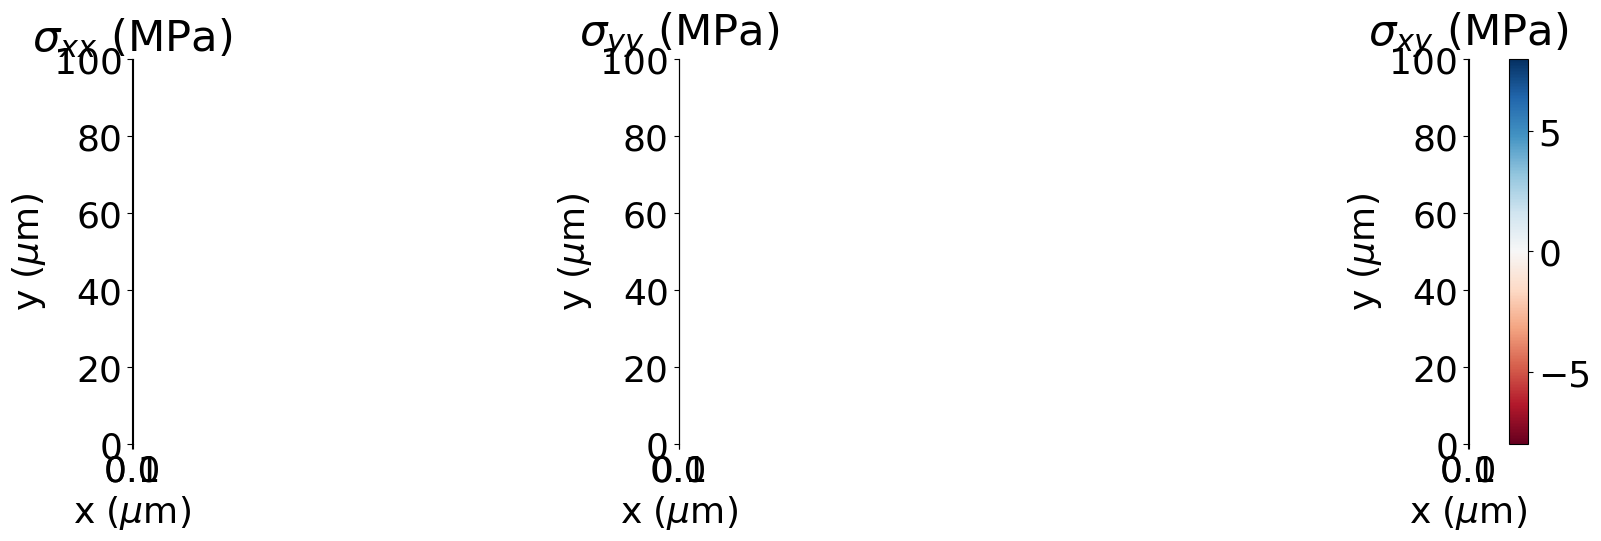

Initial force (max, median): 6.252070712570292 0.037887305926140064
Initial configuration, Ntot: 1499
box size: 0.1 micron x  100.0 micron
total dislocation density:  149.9 /micron^2
Final force (max, median): 0.004065172245330664 0.00024777545427917856
[ 0.          0.          0.         ... 47.47594006 47.72786977
 48.01805781]


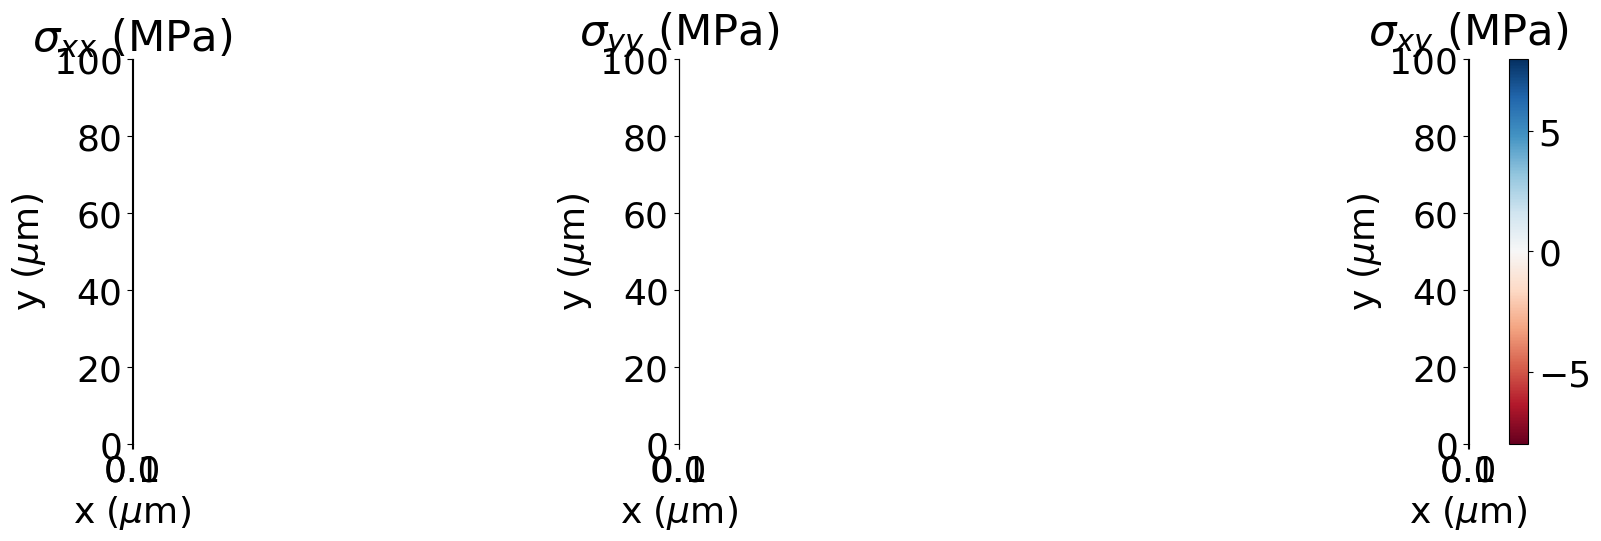

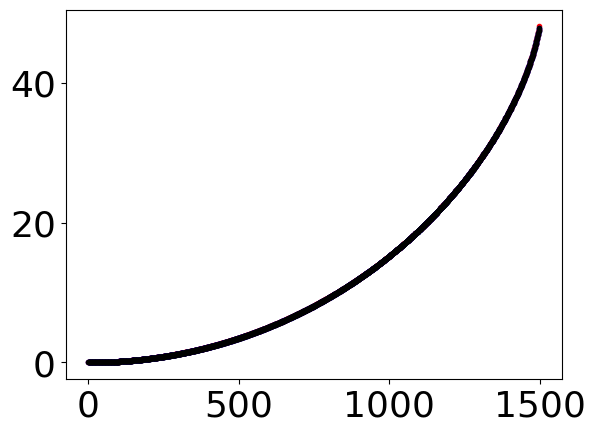

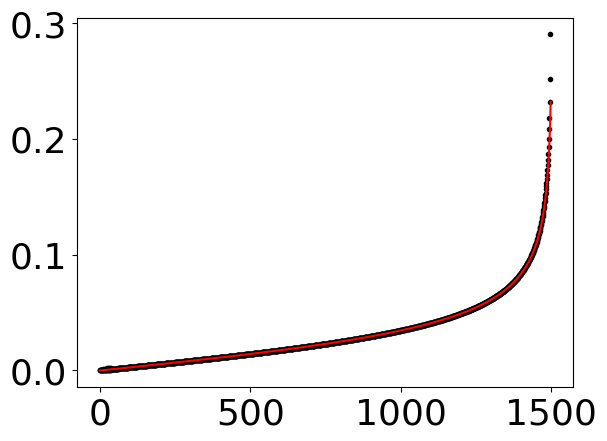

In [85]:
# Set pre-existing dislocations in pile-up an relax under applied stress
bc = 'fixed'            # set boundary conditions: 'fixed' or 'pbc'

#define numerical parameters
dt0 = 0.01           # sim_time step

#define dislocations
fill_fact = 0.5
Ntot = int(fill_fact*np.pi*(1-nu)*gs*tau0/(mu*b0)) # total number of dislocations
dmax = np.pi**2*gs / (64*fill_fact*Ntot**2)
print(dmax, gs)
dsl = dd.Dislocations(Ntot, Ntot, 0.5*np.pi, C, b0, LX=lgb, LY=gs, bc=bc, f0=f0, dmax=dmax) 
dsl.xpos = np.ones(Ntot)*lgb*0.5
dsl.ypos = np.zeros(Ntot)
dsl.ypos[1] = dmax
dx = np.zeros(Ntot)
dx[1] = dmax
for i in range(2, Ntot):
    x0 = dsl.ypos[i-1]
    dx[i] = np.pi*C / (tau0*np.sqrt((gs*fill_fact-x0)/x0))
    dsl.ypos[i] = x0 + dx[i]

yp0 = dsl.ypos.copy()
dsl.plot_stress(show_arrows=False) # plot initial configuration
fsp = dsl.calc_force()[1]
print('Initial force (max, median):', np.max(np.abs(fsp)), np.median(np.abs(fsp)))
print('Initial configuration, Ntot:',dsl.Ntot)
print('box size:',lgb,'micron x ',gs,'micron')
print('total dislocation density: ',dsl.rho,'/micron^2')

#relax dislocation configuration, i.e. move dislocations to force equilibrium
dt = dt0
for i in range(10000):
    fsp, dt = dsl.move_disl(-tau0, Ntot, "viscous", dt)
    if np.any(np.isnan(fsp)):
        print(f'Nan in loop1, iteration: {i}, timestep: {dt}')
        break

yp1 = dsl.ypos.copy()

for i in range(100000):
    fsp, dt = dsl.move_disl(-tau0, Ntot, "viscous", dt)
    if np.any(np.isnan(fsp)):
        print(f'Nan in loop2, iteration: {i}, timestep: {dt}')
        break
print('Final force (max, median):', np.max(np.abs(fsp)), np.median(np.abs(fsp)))
print(dsl.ypos[:Ntot])
dsl.plot_stress(show_arrows=False)

plt.plot(dsl.ypos, '.r')
plt.plot(yp1, '.b')
plt.plot(yp0, '.k')
plt.show()

dist = dsl.ypos[1:] - dsl.ypos[:-1]
plt.plot(dist, '.k')
plt.plot(dx, '-r')
plt.show()

if min(dist) < 0.:
    print('Warning: disorder in pile-up!!')

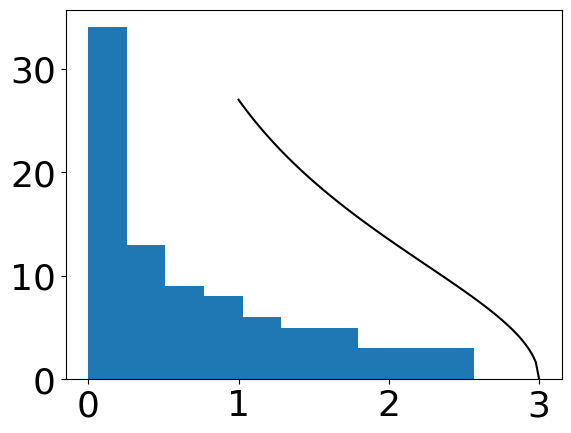

In [70]:
hc = mu*b0/(2*np.pi*(1-nu))
xv = np.linspace(1,int(gs),Ntot)
int_rho = tau0/(np.pi*hc)*(np.sqrt(xv*(gs-xv)) + gs*np.arcsin(np.sqrt(xv/gs)))
rho = tau0/(np.pi*hc)*np.sqrt((gs-xv)/xv)
plt.hist(dsl.ypos)
plt.plot(xv, rho, '-k')
plt.show()

In [ ]:
np.any(np.isnan(dsl.ypos))

In [ ]:
# run special simulation with 1 immobile dislocation in pile up with drag > 1.e5
print(f"Simulation with N_gbn={ngbn}, grain_size={gs}, dtmax={dtmax}")
gbdd = dd.GB_dislocations(temp=temp, tau0=tau0,
                   Ngbn=ngbn, len_gb_seg=lgb, grain_size=gs,
                   tfin=tfin, niter=1_000_000,
                   dtmax=dtmax, drag=drag,
                   nu=nu, mu=mu, B=b0,
                   screenout=True)
gbdd.run_sim(pudis=dsl.ypos.copy())
#gbdd.save_hdf5(f"pu1im_T{int(temp)}_H{int(gs*10)}_L{int(lgb*10)}.h5")
gbdd.plot_time_series(['n_slip_dis', 'n_absorbed', 'n_gbdis_eff'])
#gbdd.plot_time_series('plastic_slip', fs=26, lw=3)
gbdd.plot_field('displacement', fs=26, lw=4, nplot=5,
#                file=f"tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf"
               )
gbdd.plot_field('bfield', fs=26, lw=3, nplot=5,
#                file=f"tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf"
               )

Simulation with N_gbn=25, grain_size=100.0, dtmax=2441.4062499999995
Set drag: 500.0
Set nu: 0.3
Set mu: 44000.0
Set B: 0.00025
 Conducting simulation with Npu preexisting dislocations: Npu =        1483
 and Nabs absorbed dislocations: Nabs =          16
 Starting iteration for T, tau0, D2, Lgb, Ngbn   900.00000000000000        150.00000000000000        100.00000000000000       0.10000000000000001               25
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)       10000   2441.4062499999991        24.404297851562500        0.0000000000000000                            NaN        1484          16                       NaN
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)       20000   2441.4062499999991        48.818360351562497        0.0000000000000000                            NaN        1484          16                       NaN
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)       30000   2441.4062499999991        73.23242

In [ ]:
print(dsl.ypos[:Ntot])
print(gbdd.pu_dis['position'][gbdd.nout-1, :])

In [ ]:
gbdd.nout

In [ ]:
it = 190
plt.rcParams["font.size"] = 16
sp_ang = 0.5*np.pi
C = gbdd.mu*gbdd.B/(2*np.pi*(1.-gbdd.nu))   # Constant for dislocation stress field
hh = gbdd.pu_dis['position'][it, :]
ind = np.nonzero(hh)[0]
npu = len(ind)
assert npu == gbdd.glob_data['n_slip_dis'][it]
ngbn = gbdd.Ngbn
Nc = int((ngbn+1)/2) - 1
gbdx = gbdd.Dgp/(ngbn-1)
ndis = npu + ngbn
xp = np.zeros(ndis)
yp = np.zeros(ndis)
by = np.ones(ndis)
yp[0:npu] = hh[ind]  # positions of pile-up dislocations stored in first section of array, GB is at y=0
xp[0:npu] = np.ones(npu)*gbdd.Dgp*0.5  # x-positions of pile-up dislocations
xp[npu:] = gbdd.gb_node_pos + gbdd.Dgp*0.5
by[npu:] = gbdd.field_data['bfield'][it, :]  #np.zeros(ngbn) #
print(f"Number of dislocations: {npu}, Simulation time: {gbdd.sim_time[it]*1.e-6}")

#define different dislocations in box
# initialze object of class Dislocations
dsl = dd.Dislocations(ndis, npu, sp_ang, C, gbdd.B,
                      xpos=xp, ypos=yp, LX=gbdd.Dgp, LY=gbdd.D2,  #LX=50000, LY=50000, #
                      bc="fixed")
dsl.by = by
plot_stress_bfield(cutoff=150, fs=(14.2,10), 
                   file=f"sigpu1im_T{int(gbdd.temp)}_D{int(gbdd.D2*10)}_L{int(gbdd.Dgp*10)}.pdf"
                  )


In [ ]:
gbdd.plot_time_series("plast_slip_rate")
print(np.mean(gbdd.glob_data['plast_slip_rate']))

In [ ]:
gbdd.save_hdf5(f"test_tau{int(tau0)}_T{int(temp)}_H{int(gs*10)}_L{int(lgb*10)}.h5")

In [ ]:
gb1 = dd.GB_dislocations(from_file='test_tau150_T900_H10_L1.h5')
gb1.plot_time_series( ["n_slip_dis", "n_absorbed", "n_gbdis_eff"])

In [ ]:
imax = int(gb1.glob_data['n_slip_dis'][-1])
gb1.niter = 45_000_000
gb1.run_sim(pudis=gb1.pu_dis['position'][-1, :imax], bfield=gb1.field_data['bfield'][-1, :])

In [ ]:
gb1.plot_time_series( ["n_slip_dis", "n_absorbed", "n_gbdis_eff"])
gb1.plot_time_series("plast_slip_rate")

In [ ]:
gb1.nout

In [ ]:
gb1.save_hdf5(f"test_2.h5")